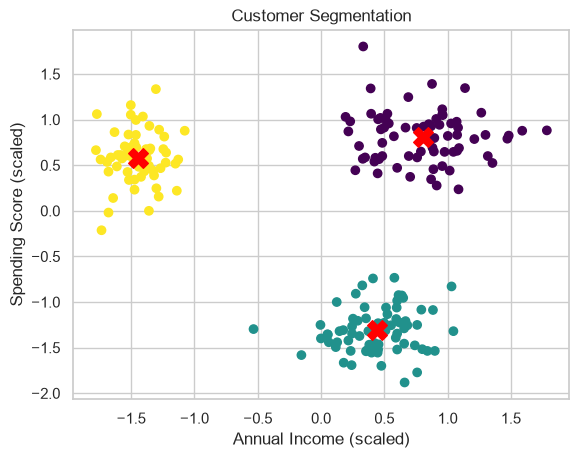

   Annual_Income_k  Spending_Score  Cluster
0        -1.326872        0.440616        2
1        -1.444408        0.528043        2
2        -1.301161        0.246755        2
3        -1.139549        0.220146        2
4        -1.462773        0.832139        2
         Annual_Income_k  Spending_Score
Cluster                                 
0               0.802053        0.806562
1               0.438215       -1.306957
2              -1.446979        0.583794


In [16]:
import sklearn.cluster as Kmeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
K = 3
X = df[['Annual_Income_k', 'Spending_Score']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = Kmeans.KMeans(n_clusters=K, init='k-means++', random_state=42)
model.fit(X_scaled)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_, cmap='viridis')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('Customer Segmentation')
plt.show()
segmented_data = pd.DataFrame(X_scaled, columns=['Annual_Income_k', 'Spending_Score'])
segmented_data['Cluster'] = model.labels_
print(segmented_data.head())
segmented_data.to_csv('segmented_customers.csv', index=False)
segment_profiles = segmented_data.groupby('Cluster').mean()
print(segment_profiles)

Cluster                                 
0               0.802053        0.806562 (VIPS)(:Earns high, Spends high)
1               0.438215       -1.306957 (Savers) (:Eanrs high but tends to save)
2              -1.446979        0.583794 (Spenders)(:Earns low but big spenders)

[399.9999999999999, 195.3663037101377, 30.346011324738928, 24.26215089047289, 21.69322725989518, 19.45807517653144, 18.00916677919613, 14.254018741725002, 12.991065281745326, 11.097190716189644]


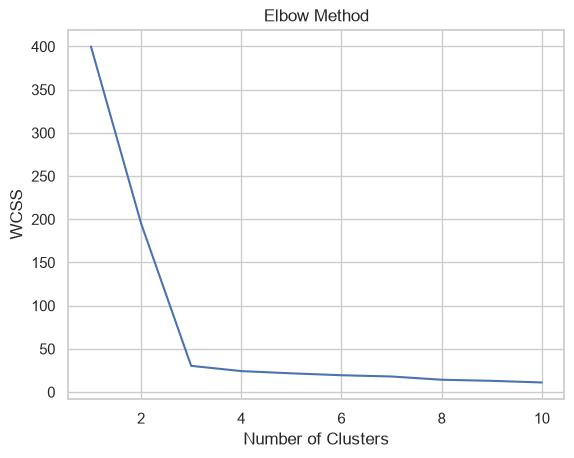

In [ ]:
import sklearn.cluster as Kmeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df[['Annual_Income_k', 'Spending_Score']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
wcss = []
for k in range(1, 11):
    kmeans = Kmeans.KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

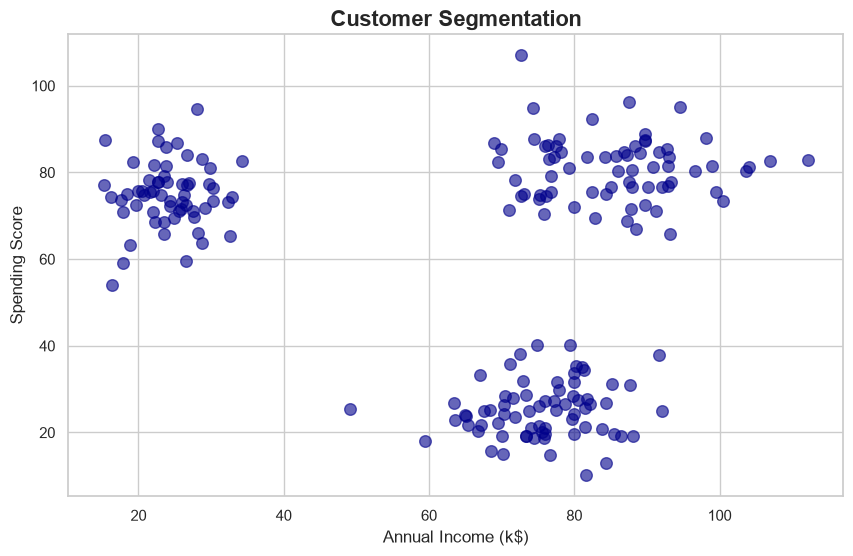

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
plt.scatter(df['Annual_Income_k'], df['Spending_Score'], color ='darkblue', alpha=0.6, s = 70)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation', fontweight='bold', fontsize=16)
plt.show()


In [7]:
import pandas as pd
import numpy as np
df = pd.read_csv('customer_segmentation_data.csv')
print('data length is:', len(df))
df.head()

data length is: 200


,CustomerID,Annual_Income_k,Spending_Score
0,1001,27.5,71.2
1,1002,24.3,73.5
2,1003,28.2,66.1
3,1004,32.6,65.4
4,1005,23.8,81.5
